<a href="https://colab.research.google.com/github/vangaricharmi-cmyk/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vangaricharmi-cmyk/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research Question

Which pages should be prioritized for content refresh or improvement based on their observed performance signals?

The decision supported by this work is which pages should receive attention first. The output will provide a ranked list of content refresh opportunities that can help a content or SEO team prioritize its work.

The analysis is intended as decision support. It identifies patterns and opportunities in the available data; it does not claim to predict Google rankings or prove that refreshing a page will cause better performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This analysis uses the anonymized FlyRank ML Internship content-refresh dataset.

The public-safe starter dataset contains page-level search, content, engagement, freshness, and performance signals. The dataset includes 30,000 rows and 44 columns in the starter release.

The analysis uses the available 90-day performance aggregates together with last-30-day and previous-30-day fields where available. The public-safe snapshot does not expose calendar dates for individual observations, so no additional date assumptions are made.

For preparation, rows without positive 90-day impressions or with content age below 90 days are excluded because they do not meet the minimum conditions for this refresh-opportunity analysis. Duplicate content IDs are also removed.

Client names, domains, URLs, private queries, credentials, and raw private client exports are not used or displayed.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

The unit of analysis is one content page.

The target label is whether the observed trend direction is "down". This is used as a measurable signal for identifying pages that may need review or refresh.

The preparation step keeps pages with positive 90-day impressions and at least 90 days of content age, removes duplicate content IDs, converts numeric fields to numeric values, fills missing numeric values with zero where appropriate, and treats missing categorical values as "unknown".

Features include search demand, competition, content length, 90-day impressions and clicks, sessions, content age, days since last update, CTR, average position, engagement rate, scroll rate, AI traffic percentage, and relevant categorical content attributes.

A transparent hand-built baseline score combines visibility, freshness risk, position opportunity, and content-depth gap. This gives a simple benchmark against which the learned models can be compared.

Three classification models are evaluated: Logistic Regression, Decision Tree, and Random Forest.

The validation uses a client-aware holdout when the data permits it, so pages from held-out clients are not mixed with their corresponding training pages. If a client-aware split cannot satisfy the required two-class condition, a stratified row holdout is used instead.

The target label and direct outcome fields are excluded from the model features to reduce leakage. The trend direction is used only to define the target and is not used as a model feature.

The main selection metric is Precision@50 because the practical decision is to identify a small ranked set of pages for review.

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Load the anonymized dataset
df = pd.read_csv(
    "https://raw.githubusercontent.com/vangaricharmi-cmyk/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"
)

print("Raw rows:", len(df))
print("Raw columns:", len(df.columns))

# Numeric columns used by the analysis
numeric_columns = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Clean numeric values
for col in numeric_columns:
    if col in df.columns:
        df[col] = (
            df[col]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )

# Clean categorical values
categorical_columns = [
    "competition_level",
    "content_type",
    "main_intent",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "impression_tier",
    "position_tier",
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].fillna("unknown").astype(str)

# Apply capstone preparation rules
df = df[
    (df["impressions_90d"] > 0) &
    (df["content_age_days"] >= 90)
].copy()

df = df.drop_duplicates(subset=["content_id"]).reset_index(drop=True)

# Define target
df["is_declining_label"] = (
    df["trend_direction"].astype(str).str.lower() == "down"
).astype(int)

# Log-transformed features
df["log_impressions_90d"] = np.log1p(df["impressions_90d"])
df["log_clicks_90d"] = np.log1p(df["clicks_90d"])
df["log_sessions_90d"] = np.log1p(df["sessions_90d"])
df["log_ai_sessions_90d"] = np.log1p(df["ai_sessions_90d"])

# Model features
model_numeric = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "log_impressions_90d",
    "log_clicks_90d",
    "log_sessions_90d",
    "log_ai_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
]

model_categorical = [
    "competition_level",
    "content_type",
    "main_intent",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "impression_tier",
    "position_tier",
]

numeric_frame = df[model_numeric].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)

categorical_frame = df[model_categorical].fillna("unknown").astype(str)

encoded_frame = pd.get_dummies(
    categorical_frame,
    prefix=model_categorical,
    dtype=float
)

X = pd.concat(
    [
        numeric_frame.reset_index(drop=True),
        encoded_frame.reset_index(drop=True)
    ],
    axis=1
)

y = df["is_declining_label"].astype(int)

# Client-aware holdout
all_indices = np.arange(len(df))
clients = df["client_id"].fillna("unknown").astype(str)
unique_clients = clients.drop_duplicates().to_numpy()

rng = np.random.default_rng(42)
shuffled_clients = rng.permutation(unique_clients)

test_client_count = max(
    1,
    int(round(len(shuffled_clients) * 0.20))
)

test_clients = set(
    shuffled_clients[:test_client_count]
)

test_mask = clients.isin(test_clients).to_numpy()

train_idx = all_indices[~test_mask]
test_idx = all_indices[test_mask]

if (
    len(train_idx) == 0
    or len(test_idx) == 0
    or y.iloc[train_idx].nunique() < 2
    or y.iloc[test_idx].nunique() < 2
):
    train_idx, test_idx = train_test_split(
        all_indices,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
    split_strategy = "stratified_row_holdout"
else:
    split_strategy = "client_holdout"

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Prepared rows:", len(df))
print("Training rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Split:", split_strategy)
print("Declining rate:", round(y.mean(), 4))

# -----------------------------
# Baseline score
# -----------------------------

def percentile_rank(series):
    return series.rank(method="average", pct=True).fillna(0)

def normalize(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            np.zeros(len(series)),
            index=series.index
        )

    return (series - minimum) / (maximum - minimum)

df["visibility_score"] = percentile_rank(
    np.log1p(df["impressions_90d"])
)

df["freshness_risk_score"] = percentile_rank(
    df["days_since_last_update"]
)

df["position_opportunity_score"] = (
    (1 - normalize(
        df["avg_position"].clip(lower=1, upper=50)
    ))
    * df["visibility_score"]
    * (df["avg_position"] > 0).astype(int)
)

df["depth_gap_score"] = (
    1 - percentile_rank(df["word_count"])
) * df["visibility_score"]

df["baseline_refresh_score"] = (
    0.40 * df["visibility_score"]
    + 0.30 * df["freshness_risk_score"]
    + 0.25 * df["position_opportunity_score"]
    + 0.05 * df["depth_gap_score"]
).clip(0, 1)

baseline_scores = df.iloc[test_idx]["baseline_refresh_score"].to_numpy()

# -----------------------------
# Models
# -----------------------------

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=5,
        min_samples_leaf=50,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced_subsample",
        max_depth=10,
        min_samples_leaf=25,
        n_estimators=200,
        n_jobs=-1,
        random_state=42
    )
}

def precision_at_k(y_true, scores, k):
    result = pd.DataFrame({
        "actual": np.asarray(y_true),
        "score": np.asarray(scores)
    })

    result = result.sort_values(
        "score",
        ascending=False
    ).head(k)

    return float(result["actual"].mean())

def metrics_for_model(y_true, scores):
    predictions = (scores >= 0.5).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC AUC": roc_auc_score(
            y_true,
            scores
        ),
        "Average Precision": average_precision_score(
            y_true,
            scores
        ),
        "Precision@50": precision_at_k(
            y_true,
            scores,
            50
        )
    }

results = {}

# Baseline
results["Baseline"] = metrics_for_model(
    y_test,
    baseline_scores
)

trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]

    results[name] = metrics_for_model(
        y_test,
        probabilities
    )

    trained_models[name] = model

# Results table
results_df = pd.DataFrame(results).T

print("\nModel evaluation:")
display(results_df.round(3))

# Select best learned model by Precision@50
learned_results = results_df.drop(index="Baseline")

best_model_name = learned_results["Precision@50"].idxmax()
best_model = trained_models[best_model_name]

print("\nBest learned model:", best_model_name)
print(
    "Selection metric: Precision@50 =",
    round(results_df.loc[best_model_name, "Precision@50"], 3)
)

# Fit best model on all prepared data for final ranking
best_model.fit(X, y)

df["model_probability"] = best_model.predict_proba(X)[:, 1]

print("\nMethodology and model preparation complete.")

Raw rows: 30000
Raw columns: 44
Prepared rows: 30000
Training rows: 27675
Test rows: 2325
Split: client_holdout
Declining rate: 0.5421

Model evaluation:


,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision,Precision@50
Baseline,0.609,0.499,0.189,0.274,0.627,0.468,0.24
Logistic Regression,0.661,0.566,0.567,0.566,0.700,0.522,0.40
Decision Tree,0.677,0.569,0.716,0.634,0.742,0.575,0.58
Random Forest,0.672,0.561,0.744,0.640,0.750,0.618,0.74



Best learned model: Random Forest
Selection metric: Precision@50 = 0.74

Methodology and model preparation complete.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [8]:
## Results

# Display the measured comparison from the same test split
results_display = results_df.copy()

display(
    results_display.round(3)
)

print("Best learned model:", best_model_name)
print(
    "Baseline Precision@50:",
    round(results_df.loc["Baseline", "Precision@50"], 3)
)
print(
    best_model_name,
    "Precision@50:",
    round(results_df.loc[best_model_name, "Precision@50"], 3)
)

print(
    "\nThe comparison uses the same held-out test split for the baseline "
    "and learned models."
)

,Accuracy,Precision,Recall,F1,ROC AUC,Average Precision,Precision@50
Baseline,0.609,0.499,0.189,0.274,0.627,0.468,0.24
Logistic Regression,0.661,0.566,0.567,0.566,0.700,0.522,0.40
Decision Tree,0.677,0.569,0.716,0.634,0.742,0.575,0.58
Random Forest,0.672,0.561,0.744,0.640,0.750,0.618,0.74


Best learned model: Random Forest
Baseline Precision@50: 0.24
Random Forest Precision@50: 0.74

The comparison uses the same held-out test split for the baseline and learned models.


## 5. Limitations

*What this work cannot claim.*

## Limitations

This analysis is based on an anonymized dataset and observed historical performance signals.

The target represents observed downward trend direction. It does not represent a guaranteed future outcome.

The model identifies pages that resemble previously observed declining pages. It does not prove that a page will decline in the future.

The analysis does not prove that refreshing a page will improve rankings, traffic, clicks, or engagement.

The model cannot establish causality between content changes and search performance.

The public-safe dataset does not provide private client context, business priorities, editorial constraints, or the full decision context a real content team may have.

The validation results are measured on the available holdout data and may not generalize to unseen datasets or future periods.

Therefore, the output should be treated as directional decision support for prioritizing review, not as an automatic content-change decision or a prediction of Google's ranking system.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [9]:
# Create a ranked refresh-opportunity queue

recommendations = df[
    [
        "content_id",
        "model_probability",
        "impressions_90d",
        "sessions_90d",
        "avg_position",
        "ctr",
        "engagement_rate",
        "scroll_rate",
        "content_age_days",
        "days_since_last_update",
        "word_count",
        "trend_direction"
    ]
].copy()

# Add practical reason codes
def get_reasons(row):

    reasons = []

    if (
        row["days_since_last_update"] >= 180
        and row["impressions_90d"] >= 500
    ):
        reasons.append("stale_visible_page")

    if (
        str(row["trend_direction"]).lower() == "down"
        and row["impressions_90d"] >= 100
    ):
        reasons.append("declining_with_demand")

    if (
        row["word_count"] > 0
        and row["word_count"] < 1200
        and row["impressions_90d"] >= 250
    ):
        reasons.append("thin_visible_page")

    if (
        row["impressions_90d"] >= 500
        and 0 < row["avg_position"] <= 20
        and row["ctr"] < 0.5
    ):
        reasons.append("low_ctr_visible_page")

    if (
        row["sessions_90d"] >= 30
        and (
            (
                row["engagement_rate"] > 0
                and row["engagement_rate"] < 30
            )
            or
            (
                row["scroll_rate"] > 0
                and row["scroll_rate"] < 30
            )
        )
    ):
        reasons.append("engagement_review_candidate")

    if not reasons:
        reasons.append("general_refresh_review")

    return "|".join(reasons)

recommendations["reason_codes"] = recommendations.apply(
    get_reasons,
    axis=1
)

def suggested_action(reasons):

    reasons = set(str(reasons).split("|"))

    if "thin_visible_page" in reasons:
        return "Expand and refresh"

    if "low_ctr_visible_page" in reasons:
        return "Refresh and review CTR"

    if (
        "stale_visible_page" in reasons
        or "declining_with_demand" in reasons
    ):
        return "Refresh"

    if "engagement_review_candidate" in reasons:
        return "Review engagement"

    return "Monitor"

recommendations["suggested_action"] = recommendations[
    "reason_codes"
].apply(suggested_action)

# Rank by model probability
recommendations = recommendations.sort_values(
    "model_probability",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = (
    recommendations.index + 1
)

# Show only safe aggregate/recommendation information
display(
    recommendations[
        [
            "rank",
            "model_probability",
            "impressions_90d",
            "avg_position",
            "ctr",
            "content_age_days",
            "days_since_last_update",
            "reason_codes",
            "suggested_action"
        ]
    ].head(20).round(3)
)

# Save the ranked queue
recommendations.to_csv(
    "/content/refresh_recommendations.csv",
    index=False
)

print(
    "\nRanked recommendation queue saved to "
    "/content/refresh_recommendations.csv"
)

,rank,model_probability,impressions_90d,avg_position,ctr,content_age_days,days_since_last_update,reason_codes,suggested_action
0,1,0.852,24516,26.9,0.09,147,20,declining_with_demand|engagement_review_candidate,Refresh
1,2,0.851,337,1.8,0.00,124,104,declining_with_demand,Refresh
2,3,0.850,2498,10.1,0.00,165,104,declining_with_demand|low_ctr_visible_page,Refresh and review CTR
3,4,0.849,1922,33.4,0.00,165,104,declining_with_demand,Refresh
4,5,0.848,625,8.1,0.00,165,104,declining_with_demand|low_ctr_visible_page,Refresh and review CTR
5,6,0.848,673,2.7,0.15,165,104,declining_with_demand|low_ctr_visible_page|eng...,Refresh and review CTR
6,7,0.848,22184,31.2,0.14,141,20,declining_with_demand,Refresh
7,8,0.847,685,34.0,0.00,165,104,declining_with_demand|engagement_review_candidate,Refresh
8,9,0.847,29616,30.1,0.17,141,20,declining_with_demand,Refresh
9,10,0.847,21928,24.4,0.17,141,20,declining_with_demand|engagement_review_candidate,Refresh



Ranked recommendation queue saved to /content/refresh_recommendations.csv


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

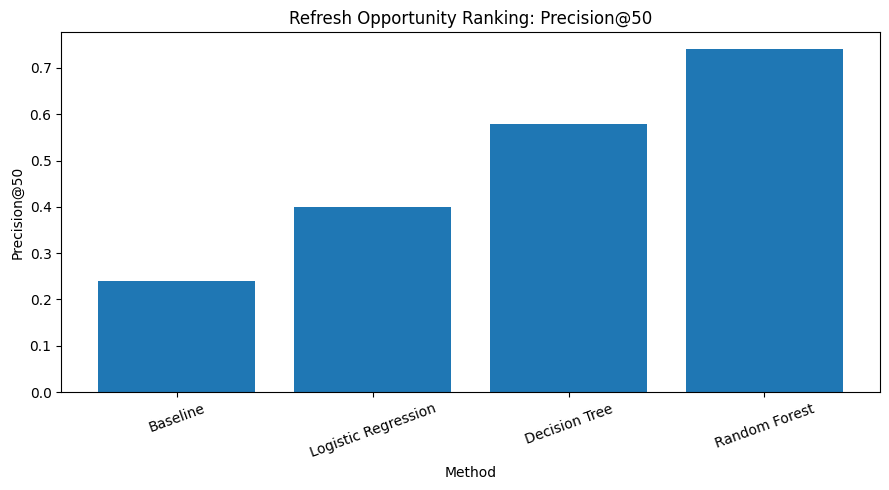

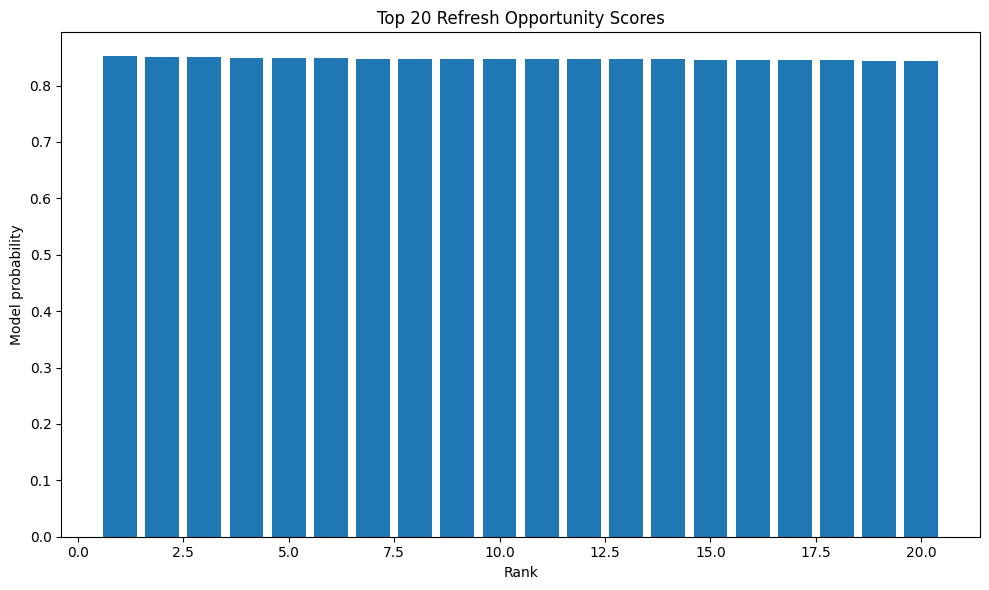

,Artifact,Purpose
0,Model vs baseline Precision@50,Compare learned ranking with the transparent b...
1,Top 20 refresh opportunity scores,Visualize the highest-scored opportunities
2,Ranked recommendation queue,Provide the action-oriented refresh queue


Charts generated successfully.


In [10]:
import matplotlib.pyplot as plt

# -----------------------------
# Chart 1: Model vs Baseline
# -----------------------------

comparison = results_df[
    ["Precision@50"]
].copy()

plt.figure(figsize=(9, 5))

plt.bar(
    comparison.index,
    comparison["Precision@50"]
)

plt.ylabel("Precision@50")
plt.xlabel("Method")
plt.title("Refresh Opportunity Ranking: Precision@50")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "/content/model_vs_baseline_precision_at_50.png",
    dpi=150
)

plt.show()


# -----------------------------
# Chart 2: Top recommendation scores
# -----------------------------

top20 = recommendations.head(20).copy()

plt.figure(figsize=(10, 6))

plt.bar(
    range(1, len(top20) + 1),
    top20["model_probability"]
)

plt.xlabel("Rank")
plt.ylabel("Model probability")
plt.title("Top 20 Refresh Opportunity Scores")

plt.tight_layout()

plt.savefig(
    "/content/top_refresh_opportunities.png",
    dpi=150
)

plt.show()


# -----------------------------
# Summary table
# -----------------------------

artifact_summary = pd.DataFrame({
    "Artifact": [
        "Model vs baseline Precision@50",
        "Top 20 refresh opportunity scores",
        "Ranked recommendation queue"
    ],
    "Purpose": [
        "Compare learned ranking with the transparent baseline",
        "Visualize the highest-scored opportunities",
        "Provide the action-oriented refresh queue"
    ]
})

display(artifact_summary)

print("Charts generated successfully.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
